In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2023-01-01
Revised on 2026-04-04

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — vignette, R to Python (_r2p)
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Maps — folium / Leaflet.js Vignette (_r2p)
==========================================

Purpose:
    Interactive maps using folium — the direct Python equivalent of R's
    leaflet package. Both wrap the same Leaflet.js library underneath.

    Sections:
      1. World / North America polygon map  (ggplot geom_polygon → geopandas)
      2. Harvard campus map                 (leaflet setView → folium.Map)
      3. COVID US counties — circle markers colored by count (RdBu palette)
      4. MA vs NY — circle markers colored by province
      5. Layer toggle — Massachusetts / New York on/off
      6. Cluster markers (markerClusterOptions → MarkerCluster)

    Data:
      ../data/covid.csv — US county COVID data with lat/long
      (same relative path as R script)

    Installation (run once in myenv terminal):
        pip install folium geopandas

    R equivalent: maps_leaflet.Rmd
    R libraries:  leaflet, leaflet.extras, tidyverse, ggmap, maps
    Python libs:  folium, geopandas, pandas, matplotlib

    Suffix _r2p: This notebook was converted from R to Python.

    Reference: Dr. Bharatendra Rai YouTube channel
    https://www.youtube.com/watch?v=SW5o8B_xtH8

Revision History:
    2023-01-01  Original R development (Harvard STAT 109)
                - R script: maps_leaflet.Rmd

    2026-04-04  Converted to Python / Jupyter Notebook (_r2p)
                - leaflet() → folium.Map()
                - addTiles() → folium.TileLayer('OpenStreetMap')
                - addProviderTiles('CartoDB') → TileLayer('CartoDB positron')
                - setView(lng, lat, zoom) → location=[lat,lng], zoom_start=zoom
                - addCircleMarkers() → folium.CircleMarker()
                - colorNumeric(RdBu) → matplotlib RdBu colormap
                - colorFactor() → dict province→color
                - addLayersControl() → folium.LayerControl() + FeatureGroup
                - markerClusterOptions() → folium.plugins.MarkerCluster()
                - map_data('world') + geom_polygon → geopandas static map
"""

"\nCreated on 2023-01-01\nRevised on 2026-04-04\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — vignette, R to Python (_r2p)\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nMaps — folium / Leaflet.js Vignette (_r2p)\n==========================================\n\nPurpose:\n    Interactive maps using folium — the direct Python equivalent of R's\n    leaflet package. Both wrap the same Leaflet.js library underneath.\n\n    Sections:\n      1. World / North America polygon map  (ggplot geom_polygon → geopandas)\n      2. Harvard campus map                 (leaflet setView → folium.Map)\n      3. COVID US counties — circle markers colored by count (RdBu palette)\n      4. MA vs NY — circle markers colored by province\n      5. Layer toggle — Massachusetts / New York on/off\n      6. Cluster markers (markerClusterOptions → MarkerCluster)\n\n    Data:\n      ../data/covid.csv — US c

# Maps — folium / Leaflet.js Vignette

## Purpose

Interactive maps using **folium** — the direct Python equivalent of R's
`leaflet` package. Both wrap the same **Leaflet.js** library underneath,
making this the most faithful R→Python translation in the toolbox.

## R leaflet → Python folium Reference

| R leaflet | Python folium |
|-----------|---------------|
| `leaflet()` | `folium.Map()` |
| `addTiles()` | `folium.TileLayer('OpenStreetMap')` |
| `addProviderTiles('CartoDB')` | `folium.TileLayer('CartoDB positron')` |
| `setView(lng, lat, zoom)` | `location=[lat, lng], zoom_start=zoom` |
| `addCircleMarkers(radius, color, popup)` | `folium.CircleMarker(radius, color, popup)` |
| `colorNumeric('RdBu', domain)` | `matplotlib.cm.RdBu` + normalize |
| `colorFactor(palette, levels)` | `dict` mapping level → color |
| `addLayersControl(overlayGroups)` | `folium.LayerControl()` + `FeatureGroup` |
| `markerClusterOptions()` | `folium.plugins.MarkerCluster()` |
| `htmlEscape(city)` | plain string (folium handles escaping) |
| `addMarkers()` | `folium.Marker()` |
| `map_data('world') + geom_polygon` | `geopandas.plot()` |

**R equivalent:** `maps_leaflet.Rmd`

**Installation:**
```bash
pip install folium geopandas
```

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import geopandas as gpd

# folium — direct Python equivalent of R leaflet
# Install: pip install folium
import folium
from folium import plugins

pd.set_option('display.max_columns', 20)

# Harvard color palette
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'

print(f'folium version : {folium.__version__}')
print('Imports complete.')

folium version : 0.20.0
Imports complete.


---

# Section 1: World / North America Polygon Map

Mirrors R:
```r
w   <- map_data('world')
icj <- map_data('world', region=c('Mexico','USA','Canada'))
ggplot(icj, aes(x=long, y=lat, group=group)) + geom_polygon(color='black')
```

`map_data('world')` → Natural Earth via geopandas (same data source).

In [3]:
# World polygon — mirrors R: map_data('world')
# Download Natural Earth countries (cached after first run)
import urllib.request, os

NE_URL   = ('https://naciscdn.org/naturalearth/110m/cultural/'
             'ne_110m_admin_0_countries.zip')
NE_CACHE = os.path.expanduser(
    '~/Library/Caches/geodatasets/ne_110m_admin_0_countries.zip')

if not os.path.exists(NE_CACHE):
    print('Downloading Natural Earth countries shapefile...')
    os.makedirs(os.path.dirname(NE_CACHE), exist_ok=True)
    urllib.request.urlretrieve(NE_URL, NE_CACHE)
    print('Download complete.')
else:
    print(f'Using cached: {NE_CACHE}')

world = gpd.read_file(f'zip://{NE_CACHE}')

# Identify name column for filtering
name_col = next((c for c in ['NAME', 'name', 'ADMIN', 'admin']
                 if c in world.columns), world.columns[0])
print(f'World shape: {world.shape}  |  Name column: {name_col}')

Using cached: /Users/otrevizo/Library/Caches/geodatasets/ne_110m_admin_0_countries.zip
World shape: (177, 169)  |  Name column: NAME


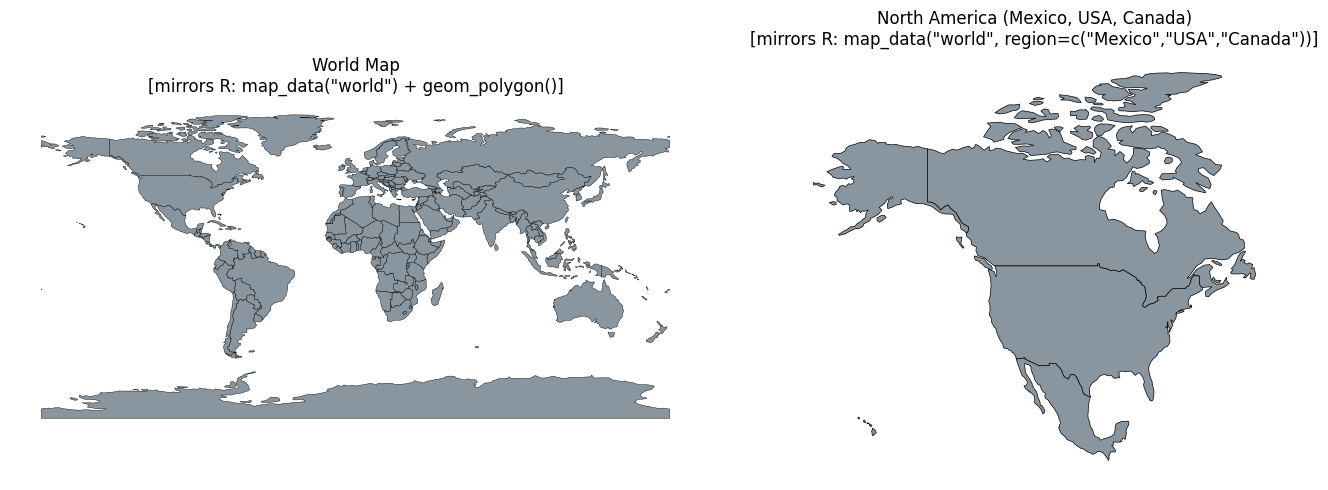

In [4]:
# North America subset — mirrors R: map_data('world', region=c('Mexico','USA','Canada'))
na_countries = ['Mexico', 'United States of America', 'Canada',
                'United States', 'USA']   # handle name variants
icj = world[world[name_col].isin(na_countries)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# World map — mirrors R: ggplot(w, aes(...)) + geom_polygon()
world.plot(ax=axes[0], color=SLATE, edgecolor='black', linewidth=0.3)
axes[0].set_title('World Map\n[mirrors R: map_data("world") + geom_polygon()]')
axes[0].set_axis_off()

# North America — mirrors R: map_data('world', region=c('Mexico','USA','Canada'))
icj.plot(ax=axes[1], color=SLATE, edgecolor='black', linewidth=0.5)
axes[1].set_title('North America (Mexico, USA, Canada)\n'
                  '[mirrors R: map_data("world", region=c("Mexico","USA","Canada"))]')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

---

# Section 2: Load COVID Data

Mirrors R:
```r
c   <- read.csv('../data/covid.csv', header=TRUE)
usa <- c %>% filter(country=='United States')
usa <- usa %>% group_by(city, province, longitude, latitude) %>%
  summarise(count=n()) %>% arrange(desc(count))
```

In [5]:
# Load COVID data — mirrors R: read.csv('../data/covid.csv', header=TRUE)
COVID_PATH = '../data/covid.csv'

try:
    covid = pd.read_csv(COVID_PATH, low_memory=False)   # Suppressed a worning with low_memory=False
    print(f'covid loaded: {covid.shape}')
    print(f'columns: {list(covid.columns)}')
except FileNotFoundError:
    print(f'File not found: {COVID_PATH}')
    print('Expected in ../data/ relative to Python/vignettes/')
    raise

covid.head()

covid loaded: (117771, 34)
columns: ['ID', 'age', 'sex', 'city', 'province', 'country', 'wuhan(0)_not_wuhan(1)', 'latitude', 'longitude', 'geo_resolution', 'date_onset_symptoms', 'date_admission_hospital', 'date_confirmation', 'symptoms', 'lives_in_Wuhan', 'travel_history_dates', 'travel_history_location', 'reported_market_exposure', 'additional_information', 'chronic_disease_binary', 'chronic_disease', 'source', 'sequence_available', 'outcome', 'date_death_or_discharge', 'notes_for_discussion', 'location', 'admin3', 'admin2', 'admin1', 'country_new', 'admin_id', 'data_moderator_initials', 'travel_history_binary']


,ID,age,sex,city,province,country,wuhan(0)_not_wuhan(1),latitude,longitude,geo_resolution,...,date_death_or_discharge,notes_for_discussion,location,admin3,admin2,admin1,country_new,admin_id,data_moderator_initials,travel_history_binary
0,000-1-,NaN,NaN,NaN,Pays de la Loire,France,1.0,47.48646,-0.81128,admin1,...,NaN,NaN,NaN,NaN,NaN,Pays de la Loire,France,12,NaN,NaN
1,000-1-,50-59,male,Snohomish County,Washington,United States,1.0,48.04818,-121.69600,admin2,...,NaN,NaN,NaN,NaN,Snohomish County,Washington,United States,2988,NaN,NaN
2,000-1-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,000-1-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,000-1-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Filter US — mirrors R: usa <- c %>% filter(country=='United States')
# Detect country column name
country_col = next((c for c in ['country', 'Country', 'country_region']
                    if c in covid.columns), None)
city_col    = next((c for c in ['city', 'City', 'admin2']
                    if c in covid.columns), None)
prov_col    = next((c for c in ['province', 'Province_State', 'state']
                    if c in covid.columns), None)
lat_col     = next((c for c in ['latitude', 'Lat', 'lat']
                    if c in covid.columns), None)
lon_col     = next((c for c in ['longitude', 'Long_', 'long', 'lon']
                    if c in covid.columns), None)

print(f'Detected columns: country={country_col}, city={city_col}, '
      f'province={prov_col}, lat={lat_col}, lon={lon_col}')

# Filter US and group by city — mirrors R dplyr chain
us_mask = covid[country_col].str.strip() == 'United States'
usa_raw = covid[us_mask].copy()

# Standardize column names for the rest of the notebook
usa_raw = usa_raw.rename(columns={
    city_col: 'city', prov_col: 'province',
    lat_col:  'latitude', lon_col: 'longitude'
})

# group_by + summarise — mirrors R
usa = (usa_raw
       .groupby(['city', 'province', 'longitude', 'latitude'],
                observed=True)
       .size()
       .reset_index(name='count')
       .sort_values('count', ascending=False))

# Drop rows with missing coordinates
usa = usa.dropna(subset=['latitude', 'longitude'])
usa['latitude']  = pd.to_numeric(usa['latitude'],  errors='coerce')
usa['longitude'] = pd.to_numeric(usa['longitude'], errors='coerce')
usa = usa.dropna(subset=['latitude', 'longitude'])

print(f'US COVID locations: {len(usa)}')
usa.head()

Detected columns: country=country, city=city, province=province, lat=latitude, lon=longitude
US COVID locations: 605


,city,province,longitude,latitude,count
391,New York City,New York,-73.944000,40.661000,2469
582,Westchester County,New York,-73.756966,41.162492,793
286,King County,Washington,-121.804000,47.491330,506
384,Nassau County,New York,-73.588254,40.739946,372
506,Snohomish County,Washington,-121.696000,48.048180,260


---

# Section 3: Harvard Campus Map

Mirrors R:
```r
leaflet() %>% addProviderTiles('CartoDB') %>%
  setView(lng=-71.116943, lat=42.374443, zoom=15)
```

The simplest folium map — one tile layer, one location, one zoom level.

In [7]:
# Harvard campus map — mirrors R: leaflet() %>% addProviderTiles('CartoDB') %>% setView(...)
harvard_map = folium.Map(
    location=[42.374443, -71.116943],   # setView(lat, lng) — note: folium uses [lat, lng]
    zoom_start=15,                       # zoom=15
    tiles='CartoDB positron'             # addProviderTiles('CartoDB')
)

# Add a marker for the campus center
folium.Marker(
    location=[42.374443, -71.116943],
    popup='Harvard University',
    tooltip='Harvard University',
    icon=folium.Icon(color='red', icon='info-sign')
).add_to(harvard_map)

print('Harvard campus map — zoom=15, CartoDB positron tiles')
print('[mirrors R: leaflet() %>% addProviderTiles("CartoDB") %>% setView(lng=-71.116943, lat=42.374443, zoom=15)]')
harvard_map

Harvard campus map — zoom=15, CartoDB positron tiles
[mirrors R: leaflet() %>% addProviderTiles("CartoDB") %>% setView(lng=-71.116943, lat=42.374443, zoom=15)]


---

# Section 4: COVID US Counties — Circle Markers Colored by Count

Mirrors R:
```r
mycolor <- colorNumeric(palette='RdBu', domain=c(1:4000))
usa %>% leaflet() %>% addProviderTiles('CartoDB') %>%
  addCircleMarkers(radius=2, color=~mycolor(count), popup=~paste0(city))
```

`colorNumeric(palette='RdBu')` → `matplotlib.cm.RdBu` colormap + normalizer.

In [8]:
# colorNumeric(palette='RdBu', domain=c(1:4000)) — mirrors R
# matplotlib RdBu colormap + Normalize to map count → [0,1] → hex color
norm      = mcolors.Normalize(vmin=1, vmax=4000)
cmap_rdbu = cm.get_cmap('RdBu')

def color_numeric(value, cmap=cmap_rdbu, normalizer=norm):
    """Map a numeric value to a hex color. Mirrors R: colorNumeric(palette='RdBu')."""
    rgba = cmap(normalizer(value))
    return mcolors.to_hex(rgba)

# Build the map — mirrors R: usa %>% leaflet() %>% addProviderTiles('CartoDB') %>% addCircleMarkers(...)
covid_map = folium.Map(
    location=[39.5, -98.35],   # center of US
    zoom_start=4,
    tiles='CartoDB positron'   # addProviderTiles('CartoDB')
)

for _, row in usa.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,                              # radius=2
        color=color_numeric(row['count']),     # color=~mycolor(count)
        fill=True,
        fill_color=color_numeric(row['count']),
        fill_opacity=0.7,
        popup=str(row['city'])                 # popup=~paste0(city)
    ).add_to(covid_map)

print(f'COVID circle markers: {len(usa)} US locations')
print('[mirrors R: addCircleMarkers(radius=2, color=~mycolor(count), popup=~paste0(city))]')
covid_map

COVID circle markers: 605 US locations
[mirrors R: addCircleMarkers(radius=2, color=~mycolor(count), popup=~paste0(city))]


/var/folders/5v/xxg4hr_92ngf6cfzt71pp34m0000gn/T/ipykernel_94044/1477720912.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rdbu = cm.get_cmap('RdBu')


---

# Section 5: MA vs NY — Circle Markers Colored by Province

Mirrors R:
```r
mycolor <- colorFactor(palette=c('red','blue'), levels=c('Massachusetts','New York'))
map %>% addCircleMarkers(data=usa, radius=2, color=~mycolor(province),
                          label=~paste0(city, '(', province, ')'))
```

`colorFactor()` → `dict` mapping province name to color.

In [9]:
# Filter MA and NY — mirrors R: filter(province=='Massachusetts' | province=='New York')
ma_ny = usa[usa['province'].isin(['Massachusetts', 'New York'])].copy()
print(f'MA + NY locations: {len(ma_ny)}')
print(ma_ny['province'].value_counts().to_string())

# colorFactor(palette=c('red','blue'), levels=c('Massachusetts','New York'))
province_colors = {'Massachusetts': 'blue', 'New York': 'red'}   # mirrors R colorFactor

# Build map — mirrors R: usa %>% leaflet() %>% addProviderTiles('OpenStreetMap') %>% addCircleMarkers(...)
ma_ny_map = folium.Map(
    location=[42.5, -72.5],
    zoom_start=7,
    tiles='OpenStreetMap'   # addProviderTiles('OpenStreetMap')
)

for _, row in ma_ny.iterrows():
    color = province_colors.get(row['province'], SLATE)
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=row['city'],
        tooltip=f"{row['city']} ({row['province']})"   # label=~paste0(city,'(',province,')')
    ).add_to(ma_ny_map)

print('[mirrors R: colorFactor + addCircleMarkers(color=~mycolor(province), label=~paste0(city,province))]')
ma_ny_map

MA + NY locations: 55
province
New York         41
Massachusetts    14
[mirrors R: colorFactor + addCircleMarkers(color=~mycolor(province), label=~paste0(city,province))]


---

# Section 6: Layer Toggle — Massachusetts / New York On/Off

Mirrors R:
```r
m <- leaflet() %>% addProviderTiles('CartoDB') %>%
  addCircleMarkers(data=MA, color='blue', group='Massachusetts') %>%
  addCircleMarkers(data=NY, color='red',  group='New York') %>%
  addLayersControl(overlayGroups=c('Massachusetts','New York'))
```

`addLayersControl(overlayGroups)` → `folium.FeatureGroup` + `folium.LayerControl()`.

In [10]:
MA = ma_ny[ma_ny['province'] == 'Massachusetts']
NY = ma_ny[ma_ny['province'] == 'New York']

# Base map — mirrors R: leaflet() %>% addProviderTiles('CartoDB')
toggle_map = folium.Map(
    location=[42.0, -73.5],
    zoom_start=7,
    tiles='CartoDB positron'
)

# Massachusetts layer — mirrors R: addCircleMarkers(data=MA, color='blue', group='Massachusetts')
ma_group = folium.FeatureGroup(name='Massachusetts', show=True)
for _, row in MA.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='blue',
        fill=True, fill_color='blue', fill_opacity=0.6,
        tooltip=row['city']
    ).add_to(ma_group)
ma_group.add_to(toggle_map)

# New York layer — mirrors R: addCircleMarkers(data=NY, color='red', group='New York')
ny_group = folium.FeatureGroup(name='New York', show=True)
for _, row in NY.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='red',
        fill=True, fill_color='red', fill_opacity=0.6,
        tooltip=row['city']
    ).add_to(ny_group)
ny_group.add_to(toggle_map)

# Layer control — mirrors R: addLayersControl(overlayGroups=c('Massachusetts','New York'))
folium.LayerControl(collapsed=False).add_to(toggle_map)

print('[mirrors R: addLayersControl(overlayGroups=c("Massachusetts","New York"))]')
print('Use the layer control (top right) to toggle MA/NY on and off.')
toggle_map

[mirrors R: addLayersControl(overlayGroups=c("Massachusetts","New York"))]
Use the layer control (top right) to toggle MA/NY on and off.


---

# Section 7: Cluster Markers

Mirrors R:
```r
usa %>% leaflet() %>% addTiles() %>%
  addCircleMarkers(radius=10, label=~htmlEscape(city), color='red',
                   clusterOptions=markerClusterOptions())
```

`markerClusterOptions()` → `folium.plugins.MarkerCluster()` — both use
the same Leaflet.markercluster plugin underneath.

In [11]:
# Cluster map — mirrors R: addCircleMarkers(clusterOptions=markerClusterOptions())
cluster_map = folium.Map(
    location=[39.5, -98.35],
    zoom_start=4,
    tiles='OpenStreetMap'   # addTiles() — default OpenStreetMap
)

# MarkerCluster — mirrors R: clusterOptions=markerClusterOptions()
marker_cluster = plugins.MarkerCluster().add_to(cluster_map)

for _, row in usa.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        color='red',
        fill=True, fill_color='red', fill_opacity=0.6,
        tooltip=str(row['city'])    # label=~htmlEscape(city)
    ).add_to(marker_cluster)

print(f'Cluster map: {len(usa)} markers clustered')
print('[mirrors R: addCircleMarkers(clusterOptions=markerClusterOptions())]')
print('Zoom in to expand clusters.')
cluster_map

Cluster map: 605 markers clustered
[mirrors R: addCircleMarkers(clusterOptions=markerClusterOptions())]
Zoom in to expand clusters.


---

# Summary

## Key Takeaways

1. **folium IS leaflet in Python:** Both wrap Leaflet.js. The translation
   is the most 1:1 of any R→Python library pair in this toolbox. Every
   R verb has a direct folium equivalent.

2. **`colorNumeric()` → matplotlib colormap:** R's `colorNumeric('RdBu', domain)`
   maps to `mcolors.Normalize()` + `cm.get_cmap('RdBu')`. The same
   color scale, the same logic, just different syntax.

3. **`colorFactor()` → dict:** R's factor-to-color mapping is simply
   a Python dict: `{'Massachusetts': 'blue', 'New York': 'red'}`.

4. **Layer toggle → FeatureGroup + LayerControl:** R's `addLayersControl(overlayGroups)`
   maps to `folium.FeatureGroup(name=...)` per layer + `folium.LayerControl()`.
   The checkbox UI in the map is identical.

5. **MarkerCluster → same Leaflet plugin:** `markerClusterOptions()` in R
   and `folium.plugins.MarkerCluster()` in Python both use the same
   underlying Leaflet.markercluster JavaScript plugin.

## Full R → Python Mapping

| R | Python |
|---|--------|
| `leaflet()` | `folium.Map(location=[lat,lng], zoom_start=z)` |
| `addTiles()` | `tiles='OpenStreetMap'` (default) |
| `addProviderTiles('CartoDB')` | `tiles='CartoDB positron'` |
| `addProviderTiles('OpenStreetMap')` | `tiles='OpenStreetMap'` |
| `setView(lng, lat, zoom)` | `location=[lat,lng], zoom_start=zoom` |
| `addCircleMarkers(radius, color, popup)` | `folium.CircleMarker(radius, color, popup)` |
| `addMarkers()` | `folium.Marker()` |
| `colorNumeric('RdBu', domain=c(1:4000))` | `mcolors.Normalize(1,4000)` + `cm.RdBu` |
| `colorFactor(palette, levels)` | `dict(level=color)` |
| `group='Massachusetts'` | `folium.FeatureGroup(name='Massachusetts')` |
| `addLayersControl(overlayGroups)` | `folium.LayerControl()` |
| `clusterOptions=markerClusterOptions()` | `plugins.MarkerCluster()` |
| `htmlEscape(city)` | `str(city)` (folium escapes automatically) |
| `popup=~paste0(city)` | `popup=str(row['city'])` |
| `label=~paste0(city,'(',province,')')` | `tooltip=f"{city} ({province})"` |
| `map_data('world') + geom_polygon` | `gpd.read_file(...).plot()` |

## References

1. Dr. Bharatendra Rai YouTube channel.
   https://www.youtube.com/watch?v=SW5o8B_xtH8
2. folium documentation: https://python-visualization.github.io/folium/
3. Leaflet.js: https://leafletjs.com
4. Natural Earth: https://www.naturalearthdata.com